In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor

Academic Integrity and Learning Statement

By submitting my work, I confirm that:

1. The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
2. I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


### Load the data

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,pIC50
0,279.273,1.74780,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.000000
1,508.626,4.75440,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.522879
2,317.755,3.45850,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.863279
3,506.606,4.81712,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.040959
4,542.854,5.73340,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000


#### Preparing Features and Target Variables and Checking Their Shapes

In [3]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (16937, 2052)
Shape of Y: (16937,)


#### Removing low variance features

In [4]:
selection = VarianceThreshold(threshold=(0.02))    
X_var = selection.fit_transform(X)
X_var.shape

(16937, 511)

Here Scalling is being skiiped as tree based are not sensititve to the scaling of data.

#### Splliting the data into train and validation (into 80:20)

In [5]:
X_train, X_val, Y_train, Y_val = train_test_split(X_var, Y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)

Shape of X_train: (13549, 511)
Shape of X_val: (3388, 511)


### Random Forest

Creates Random forest with 10 estimator and evaluates its performance using MSE, RMSE, and R² on both training and validation datasets.

In [6]:
rf_model = RandomForestRegressor(n_estimators=10, max_depth=5,  min_samples_split=2, min_samples_leaf=1, random_state=42)
rf_model.fit(X_train, Y_train)

Y_val_pred = rf_model.predict(X_val)
Y_train_pred = rf_model.predict(X_train)

rf_mse_val = mean_squared_error(Y_val, Y_val_pred)
rf_mse_train = mean_squared_error(Y_train, Y_train_pred)

rf_rmse_val = np.sqrt(rf_mse_val)
rf_rmse_train = np.sqrt(rf_mse_train)

rf_r2_val = r2_score(Y_val, Y_val_pred)
rf_r2_train = r2_score(Y_train, Y_train_pred)

print(f"Randome Forest Performance:")

print(f"Validation MSE: {rf_mse_val}")
print(f"Training MSE: {rf_mse_train}")

print(f"Validation RMSE: {rf_rmse_train}")
print(f"Training RMSE: {rf_rmse_train}")


print(f"Validation R2: {rf_r2_val}")
print(f"Training R2: {rf_r2_train}")


Randome Forest Performance:
Validation MSE: 1.478267967395207
Training MSE: 1.4342557329184165
Validation RMSE: 1.1976041637028558
Training RMSE: 1.1976041637028558
Validation R2: 0.26900225831553337
Training R2: 0.27813226179641326


As it can be seen that the MSE on the validation data is higher than training data so i will go for hyperparameter tunning to improve performance.

#### Hyperparameter Tuning 

GridSerach Cross Validation to optimize, the number of trees (n_estimators),  the depth of the trees (max_depth), min_samples_split, min_sample_leaf, max_features in the random forest model.

In [7]:
pipe = Pipeline(
    [
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1, verbose=1)),
    ]
)
grid = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['auto', 'sqrt', 'log2'],
}
grid_cv = GridSearchCV(pipe, grid, cv=5, return_train_score=True)
grid_cv.fit(X_train, Y_train)
grid_cv.cv_results_.keys()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_rf__max_depth', 'param_rf__max_features', 'param_rf__min_samples_leaf', 'param_rf__min_samples_split', 'param_rf__n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

Using a Pandas DataFrame to better visualize the cv_results_

In [8]:
cv_results = pd.DataFrame(grid_cv.cv_results_)
cols = [
    "mean_test_score",
    "std_test_score",
    "param_rf__max_depth",
    "param_rf__n_estimators",
    "param_rf__min_samples_split",
    "param_rf__min_samples_leaf",
    "param_rf__max_features"
]
cv_results[cols].sort_values("mean_test_score", ascending=False)

,mean_test_score,std_test_score,param_rf__max_depth,param_rf__n_estimators,param_rf__min_samples_split,param_rf__min_samples_leaf,param_rf__max_features
255,0.672971,0.009486,None,500,2,1,sqrt
254,0.672851,0.009797,None,300,2,1,sqrt
253,0.671457,0.009472,None,200,2,1,sqrt
252,0.669325,0.010444,None,100,2,1,sqrt
291,0.663430,0.008781,None,500,2,1,log2
...,...,...,...,...,...,...,...
247,NaN,NaN,None,500,5,4,auto
248,NaN,NaN,None,100,10,4,auto
249,NaN,NaN,None,200,10,4,auto
250,NaN,NaN,None,300,10,4,auto


In [9]:
best_max_depth = grid_cv.best_params_["rf__max_depth"]
best_n_estimators = grid_cv.best_params_["rf__n_estimators"]
best_min_samples_split = grid_cv.best_params_["rf__min_samples_split"]
best_min_samples_leaf = grid_cv.best_params_["rf__min_samples_leaf"]
best_max_features = grid_cv.best_params_["rf__max_features"]

print("Best parameters:")
print("Best max depth: ", best_max_depth)
print("Best n estimators: ", best_n_estimators)
print("Best min samples split: ", best_min_samples_split)
print("Best min samples leaf: ", best_min_samples_leaf)
print("Best max features: ", best_max_features)


Best parameters:
Best max depth:  None
Best n estimators:  500
Best min samples split:  2
Best min samples leaf:  1
Best max features:  sqrt


### Model Evaluation after tunning: RMSE and R² Score Calculation

In [10]:
best_params = grid_cv.best_params_

best_rf_model = RandomForestRegressor(
    n_estimators=best_params['rf__n_estimators'],
    max_depth=best_params['rf__max_depth'],
    min_samples_split=best_params['rf__min_samples_split'],
    min_samples_leaf=best_params['rf__min_samples_leaf'],
    max_features=best_params['rf__max_features'],
    random_state=42,
    n_jobs=-1,
    verbose=1
)

best_rf_model.fit(X_train, Y_train)

Y_val_pred = best_rf_model.predict(X_val)
rf_mse_val = mean_squared_error(Y_val, Y_val_pred)
rf_rmse_val = np.sqrt(rf_mse_val)
rf_r2_val = r2_score(Y_val, Y_val_pred)

print(f"Randome Forest Performance:")
print(f"Validation MSE: {rf_mse_val}")
print(f"Validation RMSE: {rf_rmse_val}")
print(f"Validation R2: {rf_r2_val}")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    3.6s


Randome Forest Performance:
Validation MSE: 0.6073567596656484
Validation RMSE: 0.7793309692714954
Validation R2: 0.6996644522476556


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


### Feature Importance

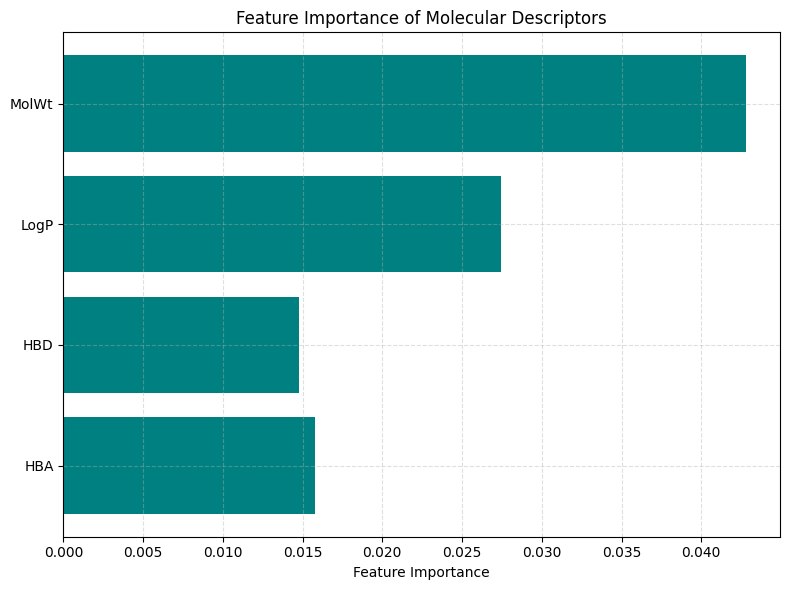

In [11]:
importances = best_rf_model.feature_importances_
desc_names = ['MolWt', 'LogP', 'HBD', 'HBA']
important_features = importances[:4]  
plt.figure(figsize=(8, 6))
plt.barh(desc_names, important_features, color='teal')
plt.xlabel('Feature Importance')
plt.title('Feature Importance of Molecular Descriptors')
plt.gca().invert_yaxis()  
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Test data

In [12]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (4235, 2052)
Shape of Y_test: (4235,)


In [13]:
X_test_var = selection.transform(X_test)

y_test_pred = best_rf_model.predict(X_test_var)

test_mse = mean_squared_error(Y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(Y_test, y_test_pred)
print("Test Set Performance:")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")
print(f"Test R^2: {test_r2}")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s


Test Set Performance:
Test MSE: 0.6165031513222895
Test RMSE: 0.7851771464595041
Test R^2: 0.6835047863924776


[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.2s finished


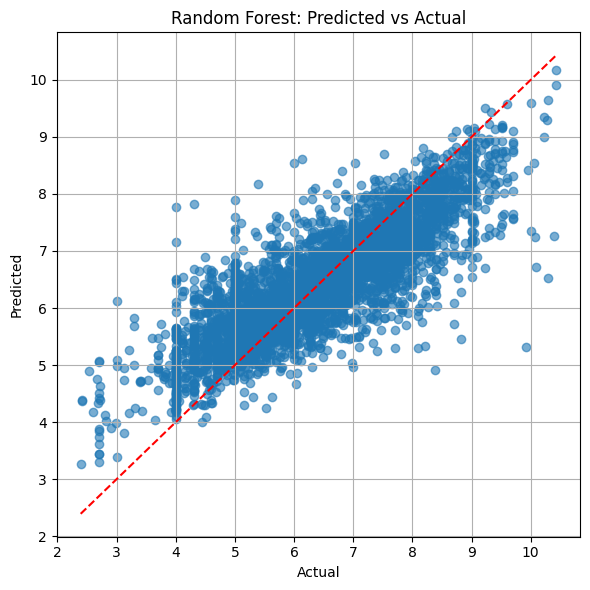

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, y_test_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Predicted vs Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

It is observed that more data are clustered near to the diagonal line, showing a better prediction than ridge regression model.

Saving the test RMSE and R-square score for final comparasion in the final task

In [15]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("Random_Forest", test_rmse, test_r2)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code